# Smart MCQ Solver

## Imports

In [ ]:
!pip install -q -U faiss-cpu bitsandbytes
!pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import random
import shutil
import pickle
from dataclasses import dataclass
from collections import Counter
from typing import Optional, Union

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import Dataset as HFDataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    BitsAndBytesConfig
)
from transformers.tokenization_utils_base import PreTrainedTokenizerBase
from transformers.utils import PaddingStrategy
from peft import PeftModel, LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

import wandb

## Environment Setup

In [ ]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nCompute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU Device: Tesla T4

Compute Device: cuda
GPU Memory Available: 15.64 GB


In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

## Hyperparameter Configuration

In [ ]:
COMMON_CONFIG = {
    "wandb_project": "dl-genai",
    "wandb_entity": "23f3001593-dl-genai-project",
    "random_state": 42,
    "test_size": 0.2,
    "option_cols": ['A','B','C','D','E'],
    "labels": ['A','B','C','D','E']
}

In [ ]:
MODEL1_CONFIG = {
    **COMMON_CONFIG,
    "wandb_run_name": "model1-bilstm-attention-fasttext",
    "max_len_question": 32,
    "max_len_option": 64,
    "embed_dim": 300,
    "fasttext_file": "wiki-news-300d-1M.vec",
    "cache_path": "filtered_fasttext_vectors.pkl",
    "hidden_dim": 64,
    "dropout": 0.4,
    "batch_size": 16,
    "learning_rate": 1e-3,
    "epochs": 15,
    "early_stopping_patience": 3
}

In [ ]:
MODEL2_CONFIG = {
    **COMMON_CONFIG,
    "wandb_run_name": "model2-deberta-v3-lora",
    "model_name": "microsoft/deberta-v3-base",
    "max_length": 128,
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.1,
    "lora_target_modules": ["query_proj", "value_proj"],
    "lora_modules_to_save": ["classifier", "pooler"],
    "learning_rate": 2e-4,
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 8,
    "gradient_accumulation_steps": 4,
    "epochs": 15,
    "warmup_ratio": 0.06,
    "weight_decay": 0.01,
    "early_stopping_patience": 3
}

In [ ]:
MODEL3_CONFIG = {
    **COMMON_CONFIG,
    "wandb_run_name": "model3-qwen2.5-3b-qlora",
    "model_name": "Qwen/Qwen2.5-3B-Instruct",
    "max_length": 824,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "lora_target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 2,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 8,
    "max_grad_norm": 1,
    "epochs": 5,
    "warmup_ratio": 0.03,
    "weight_decay": 0.0,
    "eval_batch_size": 8,
    "sanity_check_samples": 3,
    "early_stopping_patience": 2
}

In [ ]:
RAG_CONFIG = {
    "enabled": True,
    "bundle_dir": ".",
    "embedding_model_name": "BAAI/bge-large-en-v1.5",
    "reranker_model_name": "BAAI/bge-reranker-base",
    "query_instruction": "Represent this sentence for searching relevant passages: ",
    "retrieve_k": 10,
    "rerank_top_k": 3,
    "max_context_chars": 700
}

MODEL3_CONFIG["rag"] = RAG_CONFIG

### Reproducibility

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(COMMON_CONFIG["random_state"])

## Exploratory Data Analysis

### Dataset Preview

In [ ]:
train_df = pd.read_csv("train.csv")
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


### Dataset Shape

In [ ]:
train_df.shape

(2000, 8)

### Feature Names

In [ ]:
train_df.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')

### Dataset Information

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


### Dropping ID Feature

In [ ]:
train_df_without_id = train_df.drop(['id'], axis=1)
train_df_without_id.shape

(2000, 7)

### Duplicate Rows Check

In [ ]:
train_df_without_id.duplicated().sum()

np.int64(183)

183 rows have duplicate values.

In [ ]:
train_df_without_id = train_df_without_id.drop_duplicates()
train_df_without_id.shape

(1817, 7)

In [ ]:
train_df_without_id.duplicated(subset='prompt').sum()

np.int64(59)

59 rows have duplicate prompt values.

### Missing Values Count

In [ ]:
train_df_without_id.isna().sum()

,0
prompt,0
A,0
B,0
C,0
D,0
E,0
answer,0


### Answer Distribution

In [ ]:
train_df_without_id['answer'].value_counts()

,count
answer,
B,442
C,423
D,329
A,328
E,295


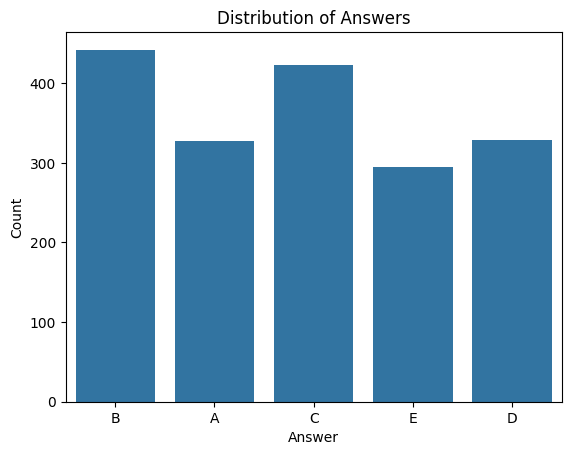

In [ ]:
ax = sns.countplot(x = train_df_without_id['answer'])
ax.set_title('Distribution of Answers')
ax.set_xlabel('Answer')
ax.set_ylabel('Count')
plt.show()

### Prompt Length Analysis

In [ ]:
prompt_length = train_df_without_id['prompt'].apply(lambda x: len(x.split()))
prompt_length.describe()

,prompt
count,1817.000000
mean,18.057237
std,6.844080
min,3.000000
25%,14.000000
50%,17.000000
75%,22.000000
max,51.000000


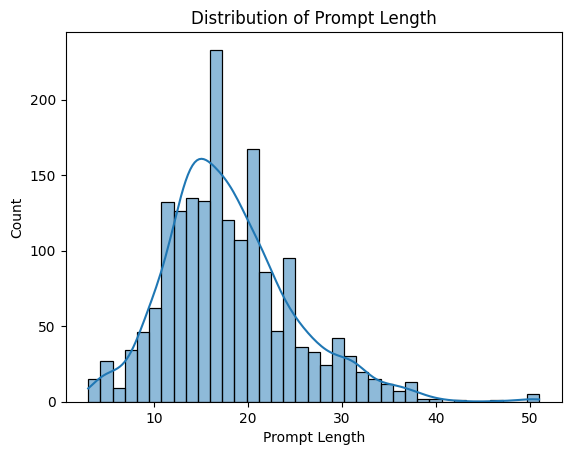

In [ ]:
ax = sns.histplot(prompt_length, kde=True)
ax.set_title('Distribution of Prompt Length')
ax.set_xlabel('Prompt Length')
ax.set_ylabel('Count')
plt.show()

### Prompt-Option Similarity

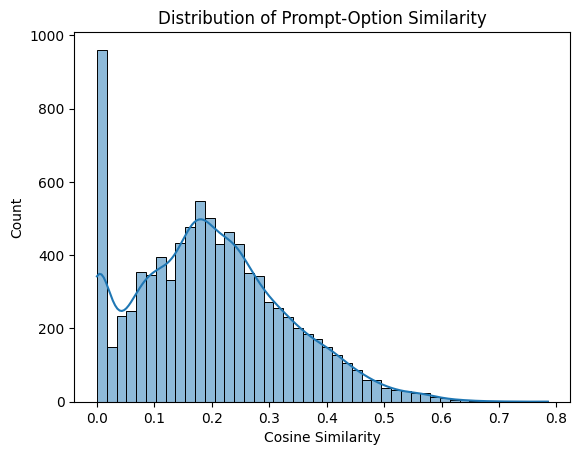

In [ ]:
similarities = []

for _, row in train_df_without_id.iterrows():
    texts = [row['prompt'], row['A'], row['B'], row['C'], row['D'], row['E']]
    tfidf = TfidfVectorizer().fit_transform(texts)
    similarities.extend(cosine_similarity(tfidf[:1], tfidf[1:]).flatten())

ax = sns.histplot(similarities, kde=True)
ax.set_title('Distribution of Prompt-Option Similarity')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
plt.show()

### Option Similarity

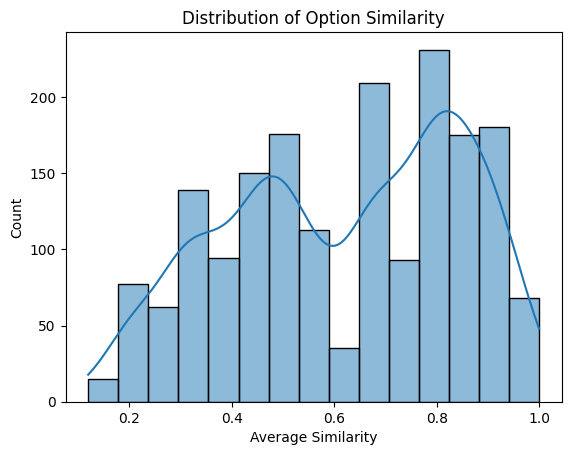

In [ ]:
avg_similarities = []

for _, row in train_df_without_id.iterrows():
    tfidf = TfidfVectorizer().fit_transform([row['A'], row['B'], row['C'], row['D'], row['E']])
    avg_similarities.append(cosine_similarity(tfidf).mean())

ax = sns.histplot(avg_similarities, kde=True)
ax.set_title('Distribution of Option Similarity')
ax.set_xlabel('Average Similarity')
ax.set_ylabel('Count')
plt.show()

## Model 1: BiLSTM with Attention & FastText Embeddings

### Train-Validation Split

In [ ]:
raw_df = pd.read_csv("train.csv")

content_cols = ['prompt'] + MODEL1_CONFIG["option_cols"] + ['answer']
raw_df = raw_df.drop_duplicates(subset=content_cols).reset_index(drop=True)

unique_prompts = raw_df['prompt'].unique()
prompt_to_answer = raw_df.drop_duplicates(subset='prompt').set_index('prompt')['answer']

train_prompts, val_prompts = train_test_split(
    unique_prompts,
    test_size=MODEL1_CONFIG["test_size"],
    random_state=MODEL1_CONFIG["random_state"],
    stratify=prompt_to_answer.loc[unique_prompts]
)

train_df_m1 = raw_df[raw_df['prompt'].isin(train_prompts)].reset_index(drop=True)
val_df_m1   = raw_df[raw_df['prompt'].isin(val_prompts)].reset_index(drop=True)

print(f"Train size: {len(train_df_m1)}, Val size: {len(val_df_m1)}")

Train size: 1449, Val size: 368


### Data Preparation

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s!?.,'\"]", '', text)
    text = re.sub(r"([!?.,'\"])", r' \1 ', text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_pairs(df):
    pairs = []
    for _, row in df.iterrows():
        q = clean_text(row['prompt'])
        opts = [clean_text(row[c]) for c in MODEL1_CONFIG["option_cols"]]
        label_idx = MODEL1_CONFIG["labels"].index(row['answer'])
        pairs.append({'question': q, 'options': opts, 'label': label_idx})
    return pairs

train_pairs = build_pairs(train_df_m1)
val_pairs = build_pairs(val_df_m1)

### Tokenization

In [ ]:
def tokenize(text):
    return text.split()

counter = Counter()
for p in train_pairs + val_pairs:
    counter.update(tokenize(p['question']))
    for opt in p['options']:
        counter.update(tokenize(opt))

candidate_words = set(counter.keys())
print("Candidate vocab size:", len(candidate_words))

Candidate vocab size: 3074


### Filtered FastText Embeddings

In [ ]:
if not os.path.exists(MODEL1_CONFIG["fasttext_file"]):
    !wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
    !unzip -q wiki-news-300d-1M.vec.zip

In [ ]:
if os.path.exists(MODEL1_CONFIG["cache_path"]):
    print("Loading cached filtered vectors...")
    with open(MODEL1_CONFIG["cache_path"], "rb") as f:
        word_vectors = pickle.load(f)
else:
    print("Streaming FastText file (one-time cost)...")
    def load_filtered_fasttext(filepath, wanted_words):
        word_vectors = {}
        with open(filepath, 'r', encoding='utf-8', newline='\n', errors='ignore') as f:
            next(f)
            for line in f:
                parts = line.rstrip().split(' ')
                word = parts[0]
                if word in wanted_words:
                    word_vectors[word] = np.asarray(parts[1:], dtype='float32')
                    if len(word_vectors) == len(wanted_words):
                        break
        return word_vectors
    word_vectors = load_filtered_fasttext(MODEL1_CONFIG["fasttext_file"], candidate_words)
    with open(MODEL1_CONFIG["cache_path"], "wb") as f:
        pickle.dump(word_vectors, f)

print("Matched vectors:", len(word_vectors), "/", len(candidate_words))

Streaming FastText file (one-time cost)...
Matched vectors: 2831 / 3074


### Building Vocabulary

In [ ]:
PAD, UNK = '<pad>', '<unk>'
vocab = [PAD, UNK] + list(word_vectors.keys())
word2idx = {w: i for i, w in enumerate(vocab)}

embedding_matrix = np.zeros((len(vocab), MODEL1_CONFIG["embed_dim"]), dtype=np.float32)
for word, idx in word2idx.items():
    if word in word_vectors:
        embedding_matrix[idx] = word_vectors[word]

print("Final vocab size:", len(vocab))

Final vocab size: 2833


### Dataset & DataLoader

In [ ]:
def encode(text, max_len):
    ids = [word2idx.get(w, word2idx[UNK]) for w in tokenize(text)][:max_len]
    ids += [word2idx[PAD]] * (max_len - len(ids))
    return ids

class MCQDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        p = self.pairs[idx]
        q_ids = torch.tensor(encode(p['question'], MODEL1_CONFIG["max_len_question"]))
        opt_ids = torch.tensor([encode(o, MODEL1_CONFIG["max_len_option"]) for o in p['options']])
        label = torch.tensor(p['label'])
        return q_ids, opt_ids, label

train_dataset = MCQDataset(train_pairs)
val_dataset   = MCQDataset(val_pairs)

train_loader = DataLoader(train_dataset, batch_size=MODEL1_CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=MODEL1_CONFIG["batch_size"], shuffle=False)

### Model Architecture

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask):
        scores = self.attn(lstm_out).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
        return context

class BiLSTMEncoder(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=word2idx[PAD]
        )
        self.lstm = nn.LSTM(embedding_matrix.shape[1], hidden_dim, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)

    def forward(self, x):
        mask = (x != word2idx[PAD]).float()
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        context = self.attention(lstm_out, mask)
        return context

class MCQModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim):
        super().__init__()
        self.encoder = BiLSTMEncoder(embedding_matrix, hidden_dim)
        combined_dim = hidden_dim * 2 * 2
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(MODEL1_CONFIG["dropout"]),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, q_ids, opt_ids):
        batch_size, num_opts, opt_len = opt_ids.shape
        q_context = self.encoder(q_ids)
        q_context_rep = q_context.unsqueeze(1).repeat(1, num_opts, 1)
        opt_flat = opt_ids.view(batch_size * num_opts, opt_len)
        opt_context = self.encoder(opt_flat)
        opt_context = opt_context.view(batch_size, num_opts, -1)
        combined = torch.cat([q_context_rep, opt_context], dim=-1)
        logits = self.classifier(combined).squeeze(-1)
        return logits

### Evaluation Metrics

In [ ]:
def map_at_3_from_ranked(true_labels, preds_ranked):
    scores = []
    for pred, true in zip(preds_ranked, true_labels):
        if true in pred:
            rank = pred.index(true) + 1
            scores.append(1.0 / rank)
        else:
            scores.append(0.0)
    return sum(scores) / len(scores)

def compute_metrics(all_logits, all_labels):
    probs = F.softmax(torch.tensor(all_logits), dim=-1)
    top1_preds = torch.argmax(probs, dim=-1).tolist()
    top3_preds = torch.topk(probs, k=3, dim=-1).indices.tolist()
    acc = accuracy_score(all_labels, top1_preds)
    f1 = f1_score(all_labels, top1_preds, average='macro')
    map3 = map_at_3_from_ranked(all_labels, top3_preds)
    return {"accuracy": acc, "f1_macro": f1, "map@3": map3}

### Training

In [ ]:
wandb.init(
    project=MODEL1_CONFIG["wandb_project"],
    entity=MODEL1_CONFIG["wandb_entity"],
    name=MODEL1_CONFIG["wandb_run_name"],
    config=MODEL1_CONFIG
)

set_seed(MODEL1_CONFIG["random_state"])
model = MCQModel(embedding_matrix, MODEL1_CONFIG["hidden_dim"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=MODEL1_CONFIG["learning_rate"])
criterion = nn.CrossEntropyLoss()

wandb.watch(model, log="all", log_freq=50)

def evaluate(loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for q_ids, opt_ids, labels in loader:
            q_ids, opt_ids = q_ids.to(device), opt_ids.to(device)
            logits = model(q_ids, opt_ids)
            all_logits.extend(logits.cpu().tolist())
            all_labels.extend(labels.tolist())
    return compute_metrics(all_logits, all_labels)

best_val_map3 = 0.0
patience_counter = 0

for epoch in range(MODEL1_CONFIG["epochs"]):
    model.train()
    total_loss = 0
    for q_ids, opt_ids, labels in train_loader:
        q_ids, opt_ids, labels = q_ids.to(device), opt_ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(q_ids, opt_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_metrics = evaluate(val_loader)

    print(f"Epoch {epoch+1}/{MODEL1_CONFIG['epochs']} - Train Loss: {train_loss:.4f} - "
          f"Val Acc: {val_metrics['accuracy']:.4f} - Val F1: {val_metrics['f1_macro']:.4f} - "
          f"Val MAP@3: {val_metrics['map@3']:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_map@3": val_metrics["map@3"],
    })

    if val_metrics["map@3"] > best_val_map3:
        best_val_map3 = val_metrics["map@3"]
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'word2idx': word2idx,
            'embedding_matrix': embedding_matrix,
            'config': MODEL1_CONFIG,
        }, "model1_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= MODEL1_CONFIG["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/15 - Train Loss: 1.3459 - Val Acc: 0.8043 - Val F1: 0.8020 - Val MAP@3: 0.8732
Epoch 2/15 - Train Loss: 0.4839 - Val Acc: 0.9511 - Val F1: 0.9503 - Val MAP@3: 0.9692
Epoch 3/15 - Train Loss: 0.1746 - Val Acc: 0.9647 - Val F1: 0.9649 - Val MAP@3: 0.9769
Epoch 4/15 - Train Loss: 0.1014 - Val Acc: 0.9674 - Val F1: 0.9678 - Val MAP@3: 0.9783
Epoch 5/15 - Train Loss: 0.1021 - Val Acc: 0.9701 - Val F1: 0.9705 - Val MAP@3: 0.9796
Epoch 6/15 - Train Loss: 0.0754 - Val Acc: 0.9755 - Val F1: 0.9757 - Val MAP@3: 0.9823
Epoch 7/15 - Train Loss: 0.0567 - Val Acc: 0.9755 - Val F1: 0.9757 - Val MAP@3: 0.9823
Epoch 8/15 - Train Loss: 0.0646 - Val Acc: 0.9755 - Val F1: 0.9746 - Val MAP@3: 0.9823
Epoch 9/15 - Train Loss: 0.0610 - Val Acc: 0.9837 - Val F1: 0.9835 - Val MAP@3: 0.9864
Epoch 10/15 - Train Loss: 0.0500 - Val Acc: 0.9837 - Val F1: 0.9835 - Val MAP@3: 0.9864
Epoch 11/15 - Train Loss: 0.0510 - Val Acc: 0.9837 - Val F1: 0.9835 - Val MAP@3: 0.9864
Epoch 12/15 - Train Loss: 0.0502 - Val Ac

### Evaluation & Logging

In [ ]:
wandb.summary["best_val_map3"] = best_val_map3

checkpoint = torch.load("model1_best.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_probs = []
with torch.no_grad():
    for q_ids, opt_ids, labels in val_loader:
        q_ids, opt_ids = q_ids.to(device), opt_ids.to(device)
        logits = model(q_ids, opt_ids)
        probs = F.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().tolist())

val_probs = np.array(all_probs)

val_probs_df = pd.DataFrame(val_probs, columns=MODEL1_CONFIG["labels"])
val_probs_df.insert(0, "id", val_df_m1["id"].values)
val_probs_df.insert(1, "prompt", val_df_m1["prompt"].values)
val_probs_df.insert(2, "true_answer", val_df_m1["answer"].values)
val_probs_df.to_csv("model1_val_probs.csv", index=False)

model_artifact = wandb.Artifact(name="model1_best", type="model")
model_artifact.add_file("model1_best.pt")
wandb.log_artifact(model_artifact)

results_artifact = wandb.Artifact(name="model1_val_probs", type="predictions")
results_artifact.add_file("model1_val_probs.csv")
wandb.log_artifact(results_artifact)

wandb.finish()

wandb: WARNING Artifact "model1_best" already exists with the same content. No new version will be created.


epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_loss,█▃▂▁▁▁▁▁▁▁▁▁
val_accuracy,▁▇▇▇▇███████
val_f1_macro,▁▇▇▇▇███████
val_map@3,▁▇▇▇████████
best_val_map3,0.98641
epoch,12
train_loss,0.05024
val_accuracy,0.9837
val_f1_macro,0.98347
val_map@3,0.98641


## Model 2: DeBERTa-v3 Fine-Tuned with LoRA

### Train-Validation Split

In [ ]:
raw_df = pd.read_csv("train.csv")

content_cols = ['prompt'] + MODEL2_CONFIG["option_cols"] + ['answer']
raw_df = raw_df.drop_duplicates(subset=content_cols).reset_index(drop=True)

unique_prompts = raw_df['prompt'].unique()
prompt_to_answer = raw_df.drop_duplicates(subset='prompt').set_index('prompt')['answer']

train_prompts, val_prompts = train_test_split(
    unique_prompts,
    test_size=MODEL2_CONFIG["test_size"],
    random_state=MODEL2_CONFIG["random_state"],
    stratify=prompt_to_answer.loc[unique_prompts]
)

train_df_m2 = raw_df[raw_df['prompt'].isin(train_prompts)].reset_index(drop=True)
val_df_m2 = raw_df[raw_df['prompt'].isin(val_prompts)].reset_index(drop=True)

print(f"Train size: {len(train_df_m2)}, Val size: {len(val_df_m2)}")

Train size: 1449, Val size: 368


### Converting to Hugging Face `Dataset`

In [ ]:
def add_label_column(df):
    df = df.copy()
    df['label'] = df['answer'].map({l: i for i, l in enumerate(MODEL2_CONFIG["labels"])})
    return df

train_df_m2 = add_label_column(train_df_m2)
val_df_m2 = add_label_column(val_df_m2)

keep_cols = ['prompt'] + MODEL2_CONFIG["option_cols"] + ['label']

raw_datasets = DatasetDict({
    "train": HFDataset.from_pandas(train_df_m2[keep_cols], preserve_index=False),
    "validation": HFDataset.from_pandas(val_df_m2[keep_cols], preserve_index=False)
})

raw_datasets

DatasetDict({
    train: Dataset({
        features: ['prompt', 'A', 'B', 'C', 'D', 'E', 'label'],
        num_rows: 1449
    })
    validation: Dataset({
        features: ['prompt', 'A', 'B', 'C', 'D', 'E', 'label'],
        num_rows: 368
    })
})

### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL2_CONFIG["model_name"])

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

In [ ]:
def preprocess_function(examples):
    num_examples = len(examples["prompt"])
    num_choices = len(MODEL2_CONFIG["option_cols"])

    first_sentences = [[prompt] * num_choices for prompt in examples["prompt"]]
    second_sentences = [
        [examples[col][i] for col in MODEL2_CONFIG["option_cols"]] for i in range(num_examples)
    ]

    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    tokenized = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        max_length=MODEL2_CONFIG["max_length"],
        padding=False
    )

    result = {
        k: [v[i:i + num_choices] for i in range(0, len(v), num_choices)]
        for k, v in tokenized.items()
    }
    result["label"] = examples["label"]
    return result

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_datasets["train"].column_names
)

tokenized_datasets

Map:   0%|          | 0/1449 [00:00<?, ? examples/s]

Map:   0%|          | 0/368 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1449
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 368
    })
})

### Data Collator

In [ ]:
@dataclass
class DataCollatorForMultipleChoice:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features):
        label_name = "label"
        labels = [feature.pop(label_name) for feature in features]
        batch_size = len(features)
        num_choices = len(features[0]["input_ids"])

        flattened_features = [
            [{k: v[i] for k, v in feature.items()} for i in range(num_choices)]
            for feature in features
        ]
        flattened_features = sum(flattened_features, [])

        batch = self.tokenizer.pad(
            flattened_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        batch = {k: v.view(batch_size, num_choices, -1) for k, v in batch.items()}
        batch["labels"] = torch.tensor(labels, dtype=torch.int64)
        return batch

data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

### Model + LoRA Setup

In [ ]:
set_seed(MODEL2_CONFIG["random_state"])

base_model = AutoModelForMultipleChoice.from_pretrained(MODEL2_CONFIG["model_name"])

lora_config = LoraConfig(
    r=MODEL2_CONFIG["lora_r"],
    lora_alpha=MODEL2_CONFIG["lora_alpha"],
    lora_dropout=MODEL2_CONFIG["lora_dropout"],
    target_modules=MODEL2_CONFIG["lora_target_modules"],
    modules_to_save=MODEL2_CONFIG["lora_modules_to_save"],
    bias="none"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias 

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

trainable params: 886,273 || all params: 185,309,186 || trainable%: 0.4783


### Evaluation Metrics

In [ ]:
def map_at_3_from_logits(logits, labels):
    top3 = np.argsort(-logits, axis=1)[:, :3]
    scores = []
    for pred, true in zip(top3, labels):
        if true in pred:
            rank = np.where(pred == true)[0][0]
            scores.append(1.0 / (rank + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "map@3": map_at_3_from_logits(logits, labels)
    }

### Training Arguments & Trainer

In [ ]:
steps_per_epoch = len(tokenized_datasets["train"]) // (
    MODEL2_CONFIG["per_device_train_batch_size"] * MODEL2_CONFIG["gradient_accumulation_steps"]
)
total_training_steps = steps_per_epoch * MODEL2_CONFIG["epochs"]
warmup_steps = int(total_training_steps * MODEL2_CONFIG["warmup_ratio"])

training_args = TrainingArguments(
    output_dir="./model2_deberta_lora",
    run_name=MODEL2_CONFIG["wandb_run_name"],
    report_to="wandb",
    learning_rate=MODEL2_CONFIG["learning_rate"],
    per_device_train_batch_size=MODEL2_CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size=MODEL2_CONFIG["per_device_eval_batch_size"],
    gradient_accumulation_steps=MODEL2_CONFIG["gradient_accumulation_steps"],
    num_train_epochs=MODEL2_CONFIG["epochs"],
    warmup_steps=warmup_steps,
    weight_decay=MODEL2_CONFIG["weight_decay"],
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="map@3",
    greater_is_better=True,
    logging_strategy="epoch",
    seed=MODEL2_CONFIG["random_state"]
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=MODEL2_CONFIG["early_stopping_patience"])]
)

### Training

In [ ]:
wandb.init(
    project=MODEL2_CONFIG["wandb_project"],
    entity=MODEL2_CONFIG["wandb_entity"],
    name=MODEL2_CONFIG["wandb_run_name"],
    config=MODEL2_CONFIG
)

train_result = trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Map@3
1,6.449444,1.466797,0.505435,0.492869,0.659873
2,4.637285,0.646484,0.796196,0.792284,0.874547
3,2.746844,0.307129,0.915761,0.914169,0.951087
4,2.071581,0.194214,0.937500,0.935645,0.961051
5,1.706559,0.157104,0.956522,0.955201,0.977808
6,1.256646,0.109497,0.970109,0.968514,0.985054
7,1.138464,0.061462,0.980978,0.980403,0.990036
8,0.988029,0.048584,0.991848,0.991730,0.995471
9,0.965293,0.046143,0.994565,0.994580,0.997283
10,0.758466,0.033325,0.994565,0.994580,0.997283


### Evaluation & Logging

In [ ]:
val_metrics = trainer.evaluate()
print(val_metrics)

predictions = trainer.predict(tokenized_datasets["validation"])
val_logits = predictions.predictions
val_probs = F.softmax(torch.tensor(val_logits), dim=1).numpy()

val_probs_df = pd.DataFrame(val_probs, columns=MODEL2_CONFIG["labels"])
val_probs_df.insert(0, "id", val_df_m2["id"].values)
val_probs_df.insert(1, "prompt", val_df_m2["prompt"].values)
val_probs_df.insert(2, "true_answer", val_df_m2["answer"].values)
val_probs_df.to_csv("model2_val_probs.csv", index=False)

model.save_pretrained("model2_lora_adapter")
tokenizer.save_pretrained("model2_lora_adapter")

merged_model = model.merge_and_unload()

save_dir = "model2_merged"
merged_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

inference_config = {**MODEL2_CONFIG}
with open(f"{save_dir}/inference_config.json", "w") as f:
    json.dump(inference_config, f, indent=2)

shutil.make_archive("model2_lora_adapter", "zip", "model2_lora_adapter")
shutil.make_archive("model2_merged", "zip", save_dir)

wandb.summary["best_val_map3"] = val_metrics["eval_map@3"]

adapter_artifact = wandb.Artifact(name="model2_lora_adapter", type="model")
adapter_artifact.add_file("model2_lora_adapter.zip")
wandb.log_artifact(adapter_artifact)

merged_artifact = wandb.Artifact(name="model2_merged", type="model")
merged_artifact.add_file("model2_merged.zip")
wandb.log_artifact(merged_artifact)

results_artifact = wandb.Artifact(name="model2_val_probs", type="predictions")
results_artifact.add_file("model2_val_probs.csv")
wandb.log_artifact(results_artifact)

wandb.finish()

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Map@3
0.656640,0.046143,12,0.994565,0.994580,0.997283


{'eval_loss': 0.046142578125, 'eval_accuracy': 0.9945652173913043, 'eval_f1_macro': 0.9945797284218122, 'eval_map@3': 0.9972826086956522}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: WARNING Artifact "model2_val_probs" already exists with the same content. No new version will be created.


eval/accuracy,▁▅▇▇▇████████
eval/f1_macro,▁▅▇▇▇████████
eval/loss,█▄▂▂▂▁▁▁▁▁▁▁▁
eval/map@3,▁▅▇▇█████████
eval/runtime,▁█▃▄▅▇▆▄▄▄▅▆▄
eval/samples_per_second,█▁▅▄▄▂▃▅▅▄▃▂▅
eval/steps_per_second,█▁▅▄▄▂▃▅▅▄▃▂▅
test/accuracy,▁
test/f1_macro,▁
test/loss,▁
+9,...


## Model 3: Qwen2.5-3B Fine-Tuned with QLoRA & RAG

### Train-Validation Split

In [ ]:
raw_df = pd.read_csv("train.csv")

content_cols = ['prompt'] + MODEL3_CONFIG["option_cols"] + ['answer']
raw_df = raw_df.drop_duplicates(subset=content_cols).reset_index(drop=True)

unique_prompts = raw_df['prompt'].unique()
prompt_to_answer = raw_df.drop_duplicates(subset='prompt').set_index('prompt')['answer']

train_prompts, val_prompts = train_test_split(
    unique_prompts,
    test_size=MODEL3_CONFIG["test_size"],
    random_state=MODEL3_CONFIG["random_state"],
    stratify=prompt_to_answer.loc[unique_prompts]
)

train_df_m3 = raw_df[raw_df['prompt'].isin(train_prompts)].reset_index(drop=True)
val_df_m3 = raw_df[raw_df['prompt'].isin(val_prompts)].reset_index(drop=True)

print(f"Train size: {len(train_df_m3)}, Val size: {len(val_df_m3)}")

Train size: 1449, Val size: 368


### RAG: Retrieval Setup

In [ ]:
rag_embedder = SentenceTransformer(RAG_CONFIG["embedding_model_name"])
rag_reranker = CrossEncoder(RAG_CONFIG["reranker_model_name"])

rag_index = faiss.read_index("rag_index.faiss")
rag_passages = pd.read_json("rag_passages.jsonl", lines=True)

with open("manifest.json") as f:
    rag_manifest = json.load(f)

assert rag_manifest["embedding_model_name"] == RAG_CONFIG["embedding_model_name"], (
    "Bundle was built with a different embedding model than RAG_CONFIG expects -- "
    f"bundle: {rag_manifest['embedding_model_name']!r}, config: {RAG_CONFIG['embedding_model_name']!r}"
)
assert rag_index.d == rag_embedder.get_embedding_dimension(), (
    f"FAISS index dim ({rag_index.d}) doesn't match embedder dim "
    f"({rag_embedder.get_embedding_dimension()}) -- wrong bundle for this embedder."
)

print(f"Loaded RAG index: {rag_index.ntotal} passages, dim={rag_index.d}")
print(f"Reranker: {RAG_CONFIG['reranker_model_name']}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Loaded RAG index: 25577 passages, dim=1024
Reranker: BAAI/bge-reranker-base


### Query Cleaning

In [ ]:
PREFIX_PHRASES = [
    "Pick the best possible answer:",
    "Select the most accurate option:",
    "Determine the correct option:",
    "Identify the correct statement:",
    "Choose the correct answer:"
]

SUFFIX_PHRASES = [
    "among the listed options.",
    "based on the given context.",
    "from the following choices.",
    "carefully."
]

def clean_query(prompt):
    q = str(prompt).strip()
    for p in PREFIX_PHRASES:
        if q.startswith(p):
            q = q[len(p):].strip()
            break
    for s in SUFFIX_PHRASES:
        if q.endswith(s):
            q = q[:-len(s)].strip()
            break
    return q

### Retrieval Function

In [ ]:
def retrieve_context(query, retrieve_k=None, rerank_top_k=None):
    if not RAG_CONFIG["enabled"]:
        return ""

    retrieve_k = retrieve_k or RAG_CONFIG["retrieve_k"]
    rerank_top_k = rerank_top_k or RAG_CONFIG["rerank_top_k"]

    clean_q = clean_query(query)
    instructed_q = RAG_CONFIG["query_instruction"] + clean_q

    q_emb = rag_embedder.encode([instructed_q], normalize_embeddings=True).astype("float32")
    _, idxs = rag_index.search(q_emb, retrieve_k)
    candidate_idxs = [i for i in idxs[0] if i != -1]
    if not candidate_idxs:
        return ""

    candidates = rag_passages.iloc[candidate_idxs]["text"].tolist()

    rerank_pairs = [[clean_q, c] for c in candidates]
    rerank_scores = rag_reranker.predict(rerank_pairs)

    ranked = sorted(zip(candidates, rerank_scores), key=lambda x: x[1], reverse=True)
    top_chunks = [c for c, _ in ranked[:rerank_top_k]]

    return " ".join(top_chunks)[:RAG_CONFIG["max_context_chars"]]

### Prompt Template

In [ ]:
MCQ_PROMPT_TEMPLATE = (
    "{context_block}"
    "Question: {prompt}\n"
    "A. {A}\n"
    "B. {B}\n"
    "C. {C}\n"
    "D. {D}\n"
    "E. {E}\n"
    "Answer:"
)

def build_mcq_prompt(row):
    context_block = ""
    if RAG_CONFIG["enabled"]:
        context = retrieve_context(row["prompt"])
        if context:
            context_block = f"Context: {context}\n\n"
    return MCQ_PROMPT_TEMPLATE.format(
        context_block=context_block,
        prompt=row["prompt"], A=row["A"], B=row["B"], C=row["C"], D=row["D"], E=row["E"],
    )

print(build_mcq_prompt(train_df_m3.iloc[0]))

Context: Martin Heidegger (26 September 1889 – 26 May 1976) was a German philosopher whose work was central to the development of phenomenology, hermeneutics, and existentialism. He has had significant impact within subsequent philosophy, social sciences and humanities, and theology. Heidegger's magnum opus, Being and Time (1927), is widely considered one of the most significant works of modern philosophy. In it, he introduced the concept of Dasein ("being-there") to describe the distinctive character of human existence, arguing that humans possess a "pre-ontological" understanding of being that shapes how they live and act, which he analyzed in terms of the unitary structure of "being-in-the-world".

Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. Th

### Tokenizer & Verifying Option-Letter Token IDs

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL3_CONFIG["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

sample_prompt = build_mcq_prompt(train_df_m3.iloc[0])
prompt_ids = tokenizer.encode(sample_prompt, add_special_tokens=False)

OPTION_TOKEN_IDS = {}
for letter in MODEL3_CONFIG["labels"]:
    full_ids = tokenizer.encode(sample_prompt + " " + letter, add_special_tokens=False)
    answer_token_ids = full_ids[len(prompt_ids):]
    assert len(answer_token_ids) == 1, (
        f"Letter '{letter}' encodes to {len(answer_token_ids)} tokens in-context "
        f"({answer_token_ids}) — template needs adjustment so each option is a single token."
    )
    OPTION_TOKEN_IDS[letter] = answer_token_ids[0]

print("Verified option-letter token ids:")
for letter, tid in OPTION_TOKEN_IDS.items():
    print(f"  {letter} -> id {tid} -> {repr(tokenizer.decode([tid]))}")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Verified option-letter token ids:
  A -> id 362 -> ' A'
  B -> id 425 -> ' B'
  C -> id 356 -> ' C'
  D -> id 422 -> ' D'
  E -> id 468 -> ' E'


### Building Training Sequences with Loss Masking

In [ ]:
def encode_example(row):
    prompt_text = build_mcq_prompt(row)
    full_text = prompt_text + " " + row["answer"]

    full_ids = tokenizer.encode(full_text, add_special_tokens=False)
    if len(full_ids) > MODEL3_CONFIG["max_length"]:
        full_ids = full_ids[-MODEL3_CONFIG["max_length"]:]

    labels = [-100] * len(full_ids)
    labels[-1] = full_ids[-1]

    return {
        "input_ids": full_ids,
        "attention_mask": [1] * len(full_ids),
        "labels": labels,
        "label": MODEL3_CONFIG["labels"].index(row["answer"])
    }

train_dataset_m3 = HFDataset.from_list([encode_example(r) for _, r in train_df_m3.iterrows()])
val_dataset_m3 = HFDataset.from_list([encode_example(r) for _, r in val_df_m3.iterrows()])

train_dataset_m3

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'label'],
    num_rows: 1449
})

### Data Collator

In [ ]:
@dataclass
class DataCollatorForCausalMCQ:
    tokenizer: PreTrainedTokenizerBase
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = ((max_len + self.pad_to_multiple_of - 1) // self.pad_to_multiple_of) * self.pad_to_multiple_of

        input_ids, attention_mask, labels = [], [], []
        pad_id = self.tokenizer.pad_token_id

        for f in features:
            pad_len = max_len - len(f["input_ids"])
            input_ids.append(f["input_ids"] + [pad_id] * pad_len)
            attention_mask.append(f["attention_mask"] + [0] * pad_len)
            labels.append(f["labels"] + [-100] * pad_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

data_collator_m3 = DataCollatorForCausalMCQ(tokenizer=tokenizer)

### Model + QLoRA Setup

In [ ]:
set_seed(MODEL3_CONFIG["random_state"])

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

base_model_m3 = AutoModelForCausalLM.from_pretrained(
    MODEL3_CONFIG["model_name"],
    quantization_config=bnb_config,
    device_map="auto"
)
base_model_m3.config.pad_token_id = tokenizer.pad_token_id
base_model_m3 = prepare_model_for_kbit_training(base_model_m3)

lora_config_m3 = LoraConfig(
    r=MODEL3_CONFIG["lora_r"],
    lora_alpha=MODEL3_CONFIG["lora_alpha"],
    lora_dropout=MODEL3_CONFIG["lora_dropout"],
    target_modules=MODEL3_CONFIG["lora_target_modules"],
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model_m3 = get_peft_model(base_model_m3, lora_config_m3)
model_m3.print_trainable_parameters()

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 7,372,800 || all params: 3,093,311,488 || trainable%: 0.2383


### Sanity Check: Option-Logit Extraction on the Base Model

In [ ]:
def get_option_logits(model, prompts, option_token_ids, tokenizer, max_length):
    model.eval()
    enc = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True,
                     max_length=max_length).to(model.device)
    with torch.no_grad():
        out = model(**enc)
    last_token_idx = enc["attention_mask"].sum(dim=1) - 1
    batch_idx = torch.arange(out.logits.size(0))
    next_token_logits = out.logits[batch_idx, last_token_idx, :]
    option_ids = torch.tensor([option_token_ids[l] for l in MODEL3_CONFIG["labels"]])
    return next_token_logits[:, option_ids].float().cpu()

sanity_prompts = [build_mcq_prompt(r) for _, r in val_df_m3.head(MODEL3_CONFIG["sanity_check_samples"]).iterrows()]
sanity_logits = get_option_logits(model_m3, sanity_prompts, OPTION_TOKEN_IDS, tokenizer, MODEL3_CONFIG["max_length"])
sanity_probs = F.softmax(sanity_logits, dim=-1)

print("Sanity-check option probabilities (untrained adapter):")
print(pd.DataFrame(sanity_probs.numpy(), columns=MODEL3_CONFIG["labels"]).round(3))

Sanity-check option probabilities (untrained adapter):
     A    B    C    D    E
0  0.0  0.0  1.0  0.0  0.0
1  1.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  1.0


### Training Arguments & Trainer

In [ ]:
steps_per_epoch_m3 = len(train_dataset_m3) // (
    MODEL3_CONFIG["per_device_train_batch_size"] * MODEL3_CONFIG["gradient_accumulation_steps"]
)
total_training_steps_m3 = steps_per_epoch_m3 * MODEL3_CONFIG["epochs"]
warmup_steps_m3 = int(total_training_steps_m3 * MODEL3_CONFIG["warmup_ratio"])

training_args_m3 = TrainingArguments(
    output_dir="./model3_qlora",
    run_name=MODEL3_CONFIG["wandb_run_name"],
    report_to="wandb",
    learning_rate=MODEL3_CONFIG["learning_rate"],
    per_device_train_batch_size=MODEL3_CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size=MODEL3_CONFIG["per_device_eval_batch_size"],
    gradient_accumulation_steps=MODEL3_CONFIG["gradient_accumulation_steps"],
    num_train_epochs=MODEL3_CONFIG["epochs"],
    warmup_steps=warmup_steps_m3,
    weight_decay=MODEL3_CONFIG["weight_decay"],
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    fp16=True,
    max_grad_norm=MODEL3_CONFIG["max_grad_norm"],
    gradient_checkpointing=True,
    remove_unused_columns=False,
    seed=MODEL3_CONFIG["random_state"]
)

In [ ]:
trainer_m3 = Trainer(
    model=model_m3,
    args=training_args_m3,
    train_dataset=train_dataset_m3.remove_columns(["label"]),
    eval_dataset=val_dataset_m3.remove_columns(["label"]),
    processing_class=tokenizer,
    data_collator=data_collator_m3,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=MODEL3_CONFIG["early_stopping_patience"])]
)

### Training

In [ ]:
wandb.init(
    project=MODEL3_CONFIG["wandb_project"],
    entity=MODEL3_CONFIG["wandb_entity"],
    name=MODEL3_CONFIG["wandb_run_name"],
    config=MODEL3_CONFIG
)

train_result_m3 = trainer_m3.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss
1,0.225332,0.000583
2,0.000118,0.000059
3,0.000029,0.000032
4,0.000018,0.000024
5,0.000014,0.000022


### Evaluation Metrics: Extracting Option Probabilities

In [ ]:
@torch.no_grad()
def predict_option_probs(model, df, option_token_ids, tokenizer, max_length, batch_size=None):
    model.eval()
    option_ids = torch.tensor([option_token_ids[l] for l in MODEL3_CONFIG["labels"]])
    all_probs = []

    for step, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc="Scoring validation prompts")):
        prompt = build_mcq_prompt(row)
        input_ids = tokenizer(
            prompt, return_tensors="pt", truncation=True, max_length=max_length
        ).input_ids.to(model.device)

        out = model(input_ids=input_ids, logits_to_keep=1)
        next_token_logits = out.logits[0, -1, :]
        option_logits = next_token_logits[option_ids].float().cpu()
        all_probs.append(F.softmax(option_logits, dim=-1))

        if (step + 1) % 50 == 0:
            torch.cuda.empty_cache()

    return torch.stack(all_probs, dim=0).numpy()

val_probs_m3 = predict_option_probs(
    trainer_m3.model, val_df_m3, OPTION_TOKEN_IDS, tokenizer,
    MODEL3_CONFIG["max_length"], MODEL3_CONFIG["eval_batch_size"]
)

Scoring validation prompts:   0%|          | 0/368 [00:00<?, ?it/s]

### Evaluation & Logging

In [ ]:
val_labels_m3 = val_df_m3["answer"].map({l: i for i, l in enumerate(MODEL3_CONFIG["labels"])}).values
top1_preds_m3 = np.argmax(val_probs_m3, axis=1)

val_acc_m3 = accuracy_score(val_labels_m3, top1_preds_m3)
val_f1_m3 = f1_score(val_labels_m3, top1_preds_m3, average="macro")
val_map3_m3 = map_at_3_from_logits(val_probs_m3, val_labels_m3)

print(f"Validation Accuracy: {val_acc_m3:.4f}")
print(f"Validation F1 (macro): {val_f1_m3:.4f}")
print(f"Validation MAP@3: {val_map3_m3:.4f}")

val_probs_df_m3 = pd.DataFrame(val_probs_m3, columns=MODEL3_CONFIG["labels"])
val_probs_df_m3.insert(0, "id", val_df_m3["id"].values)
val_probs_df_m3.insert(1, "prompt", val_df_m3["prompt"].values)
val_probs_df_m3.insert(2, "true_answer", val_df_m3["answer"].values)
val_probs_df_m3.to_csv("model3_val_probs.csv", index=False)

inference_meta_m3 = {
    **MODEL3_CONFIG,
    "option_token_ids": OPTION_TOKEN_IDS,
    "prompt_template": MCQ_PROMPT_TEMPLATE,
    "rag_bundle_dir": "rag_bundle",
    "rag_embedder_dir": "rag_embedder",
    "rag_reranker_dir": "rag_reranker"
}

model_m3.save_pretrained("model3_lora_adapter")
tokenizer.save_pretrained("model3_lora_adapter")
with open("model3_lora_adapter/inference_config.json", "w") as f:
    json.dump(inference_meta_m3, f, indent=2)
shutil.make_archive("model3_lora_adapter", "zip", "model3_lora_adapter")

del model_m3, base_model_m3
torch.cuda.empty_cache()

base_model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL3_CONFIG["model_name"], dtype=torch.float16, device_map="auto"
)
merged_model_m3 = PeftModel.from_pretrained(base_model_fp16, "model3_lora_adapter")
merged_model_m3 = merged_model_m3.merge_and_unload()

save_dir_m3 = "model3_merged"
merged_model_m3.save_pretrained(save_dir_m3)
tokenizer.save_pretrained(save_dir_m3)
with open(f"{save_dir_m3}/inference_config.json", "w") as f:
    json.dump(inference_meta_m3, f, indent=2)

rag_bundle_dst = os.path.join(save_dir_m3, "rag_bundle")
os.makedirs(rag_bundle_dst, exist_ok=True)

rag_bundle_files = ["rag_index.faiss", "rag_passages.jsonl", "manifest.json"]
missing_files = []
for fname in rag_bundle_files:
    src_path = os.path.join(RAG_CONFIG["bundle_dir"], fname)
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(rag_bundle_dst, fname))
    else:
        missing_files.append(src_path)

if missing_files:
    raise FileNotFoundError(
        f"Missing expected RAG bundle file(s): {missing_files}. "
        f"Check that RAG_CONFIG['bundle_dir'] ({RAG_CONFIG['bundle_dir']!r}) matches where you uploaded the files."
    )

print(f"Copied {len(rag_bundle_files)} RAG bundle files into {rag_bundle_dst}")

rag_embedder.save(os.path.join(save_dir_m3, "rag_embedder"))
rag_reranker.save(os.path.join(save_dir_m3, "rag_reranker"))

shutil.make_archive(save_dir_m3, "zip", save_dir_m3)

wandb.summary["best_val_map3"] = val_map3_m3
wandb.log({"accuracy": val_acc_m3, "f1_macro": val_f1_m3, "map@3": val_map3_m3})

adapter_artifact_m3 = wandb.Artifact(name="model3_lora_adapter", type="model")
adapter_artifact_m3.add_file("model3_lora_adapter.zip")
wandb.log_artifact(adapter_artifact_m3)

merged_artifact_m3 = wandb.Artifact(name="model3_merged", type="model")
merged_artifact_m3.add_file(f"{save_dir_m3}.zip")
wandb.log_artifact(merged_artifact_m3)

results_artifact_m3 = wandb.Artifact(name="model3_val_probs", type="predictions")
results_artifact_m3.add_file("model3_val_probs.csv")
wandb.log_artifact(results_artifact_m3)

wandb.finish()

Validation Accuracy: 1.0000
Validation F1 (macro): 1.0000
Validation MAP@3: 1.0000


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Copied 3 RAG bundle files into model3_merged/rag_bundle


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

accuracy,▁
eval/loss,█▁▁▁▁
eval/runtime,▁█▇▇▁
eval/samples_per_second,█▁▂▂█
eval/steps_per_second,█▁▃▃█
f1_macro,▁
map@3,▁
train/epoch,▁▁▃▃▅▅▆▆███
train/global_step,▁▁▃▃▅▅▆▆████
train/grad_norm,█▂▁▁▁
+2,...


## Ensemble Learning

### Loading Validation Probability Files

In [ ]:
model1_val = pd.read_csv("model1_val_probs.csv")
model2_val = pd.read_csv("model2_val_probs.csv")
model3_val = pd.read_csv("model3_val_probs.csv")

LABELS = COMMON_CONFIG["labels"]

for name, df in [("model1", model1_val), ("model2", model2_val), ("model3", model3_val)]:
    dup_count = df["id"].duplicated().sum()
    if dup_count > 0:
        print(f"WARNING: {name}_val_probs.csv has {dup_count} duplicate id(s).")

### Merging Predictions Across Models

In [ ]:
merged = model1_val[["id", "true_answer"] + LABELS].rename(
    columns={l: f"{l}_m1" for l in LABELS}
)
merged = merged.merge(
    model2_val[["id", "true_answer"] + LABELS].rename(columns={l: f"{l}_m2" for l in LABELS}),
    on="id", suffixes=("", "_check2")
)
merged = merged.merge(
    model3_val[["id", "true_answer"] + LABELS].rename(columns={l: f"{l}_m3" for l in LABELS}),
    on="id", suffixes=("", "_check3")
)

assert (merged["true_answer"] == merged["true_answer_check2"]).all()
assert (merged["true_answer"] == merged["true_answer_check3"]).all()
merged = merged.drop(columns=["true_answer_check2", "true_answer_check3"])

print(f"Merged validation set: {len(merged)} rows")

probs_m1 = merged[[f"{l}_m1" for l in LABELS]].values
probs_m2 = merged[[f"{l}_m2" for l in LABELS]].values
probs_m3 = merged[[f"{l}_m3" for l in LABELS]].values
true_answer = merged["true_answer"].values

Merged validation set: 368 rows


### MAP@3 Scoring Utilities

In [ ]:
def top3_labels_from_probs(prob_matrix, labels=LABELS):
    top3_idx = np.argsort(-prob_matrix, axis=1)[:, :3]
    return [[labels[i] for i in row] for row in top3_idx]

def map_at_3_ensemble(true_labels, prob_matrix, labels=LABELS):
    top3_preds = top3_labels_from_probs(prob_matrix, labels)
    scores = []
    for pred, true in zip(top3_preds, true_labels):
        if true in pred:
            scores.append(1.0 / (pred.index(true) + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

### Test-Score-Informed Ensemble Weights

In [ ]:
SUBMISSION_MAP3 = {
    "model1": 0.73441,
    "model2": 0.75353,
    "model3": 0.75103,
}

RANDOM_BASELINE_MAP3 = (1/5) * (1 + 1/2 + 1/3)

skill_scores = {
    name: max(0.0, SUBMISSION_MAP3[name] - RANDOM_BASELINE_MAP3)
    for name in ["model1", "model2", "model3"]
}
total_skill = sum(skill_scores.values())

ensemble_weights = {
    name: skill_scores[name] / total_skill
    for name in ["model1", "model2", "model3"]
}

print("Ensemble weights (test-score-informed):")
for name in ["model1", "model2", "model3"]:
    print(f"  {name}: {ensemble_weights[name]:.4f}")

w1, w2, w3 = ensemble_weights["model1"], ensemble_weights["model2"], ensemble_weights["model3"]

Ensemble weights (test-score-informed):
  model1: 0.3229
  model2: 0.3397
  model3: 0.3375


### Applying Weighted-Average Ensemble

In [ ]:
combined_val_probs = w1 * probs_m1 + w2 * probs_m2 + w3 * probs_m3
val_map3 = map_at_3_ensemble(true_answer, combined_val_probs)
print(f"Weighted-average ensemble MAP@3 on validation: {val_map3:.4f}")

Weighted-average ensemble MAP@3 on validation: 1.0000


### Saving Ensemble Config

In [ ]:
ensemble_config = {
    "method": "weighted_average",
    "weights": {
        "model1": float(w1),
        "model2": float(w2),
        "model3": float(w3),
    },
    "labels": LABELS,
    "submission_scores_used": SUBMISSION_MAP3
}

with open("ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved ensemble_config.json:")
print(json.dumps(ensemble_config, indent=2))

wandb.init(
    project=COMMON_CONFIG["wandb_project"],
    entity=COMMON_CONFIG["wandb_entity"],
    name="ensemble-weighted-average",
    config=ensemble_config
)
wandb.summary["val_map3"] = val_map3
wandb.log({
    "weight_model1": w1,
    "weight_model2": w2,
    "weight_model3": w3,
})

config_artifact = wandb.Artifact(name="ensemble_config", type="config")
config_artifact.add_file("ensemble_config.json")
wandb.log_artifact(config_artifact)

wandb.finish()

Saved ensemble_config.json:
{
  "method": "weighted_average",
  "weights": {
    "model1": 0.3228735904662399,
    "model2": 0.33966068758029916,
    "model3": 0.3374657219534608
  },
  "labels": [
    "A",
    "B",
    "C",
    "D",
    "E"
  ],
  "submission_scores_used": {
    "model1": 0.73441,
    "model2": 0.75353,
    "model3": 0.75103
  }
}


wandb: WARNING Artifact "ensemble_config" already exists with the same content. No new version will be created.


weight_model1,▁
weight_model2,▁
weight_model3,▁
val_map3,1
weight_model1,0.32287
weight_model2,0.33966
weight_model3,0.33747
